# CVL1MLE Norm-Range Sensitivity Demo

This notebook studies whether widening the post-IPCW `CVL1MLE` norm-factor range improves performance enough to justify the extra computation. It uses the package `RightCensoredObservedL1Tuner` directly on the truncated-normal right-censored setup.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import RightCensoredObservedL1MLE
from haldensity.censoring.right.comparison import (
    evaluate_density_on_grid,
    evaluate_survival_on_grid,
)
from haldensity.censoring.right.metrics import incomplete_loglik
from haldensity.censoring.tuners.right_tuners import (
    RightCensoredInitTuner,
    RightCensoredObservedL1Tuner,
)
from haldensity.utils import TruncatedNormal

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 3
N = 200
CV_FOLDS = 5
STAGE1_N_TRIALS = 25
N_GRID_POINTS = 200
PILOT_SEEDS = list(range(1, 16))
POINTWISE_GRID = np.arange(0.05, 1.0, 0.05)

REFERENCE_TRUNCATED_NORMAL = {
    "mean": 0.5,
    "std": 0.15,
    "lower": 0.0,
    "upper": 1.0,
}

RANGE_CONFIGS = {
    "CVL1MLE [1.0, 2.0]": [float(x) for x in np.round(np.linspace(1.0, 2.0, 20), 2)],
    "CVL1MLE [0.75, 2.0]": [float(x) for x in np.round(np.linspace(0.75, 2.0, 20), 2)],
    "CVL1MLE [0.5, 2.0]": [float(x) for x in np.round(np.linspace(0.5, 2.0, 20), 2)],
}

STAGE1_OVERRIDES = {
    "basis_order": [0, 1, 2],
    "norm_constraint": {"low": 1.0, "high": 500.0, "log": False},
}

OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.1,
    "n_iterations": 30000,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 100,
}

run_config = pd.DataFrame([
    {
        "representative_seed": REPRESENTATIVE_SEED,
        "n": N,
        "cv_folds": CV_FOLDS,
        "stage1_n_trials": STAGE1_N_TRIALS,
        "pilot_n_seeds": len(PILOT_SEEDS),
        "range_names": "; ".join(RANGE_CONFIGS.keys()),
    }
])
display(run_config)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,n,cv_folds,stage1_n_trials,pilot_n_seeds,range_names
0,3,200,5,25,15,"CVL1MLE [1.0, 2.0]; CVL1MLE [0.75, 2.0]; CVL1M..."


In [2]:
def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict:
    np.random.seed(seed)
    sampler = TruncatedNormal(**REFERENCE_TRUNCATED_NORMAL)
    t_event = sampler.generate_samples(n)
    t_cens = np.random.uniform(0.0, 1.0, size=n)
    observed_time = np.minimum(t_event, t_cens)
    delta = (t_event <= t_cens).astype(int)
    return {
        "observed_data": pd.DataFrame({"T": observed_time, "Delta": delta}),
        "truth": {
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
    }


def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    result = tuner.optimize(n_trials=STAGE1_N_TRIALS)
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": float(time.perf_counter() - tic),
    }


def compress_theta_to_support(estimator, support: np.ndarray) -> np.ndarray:
    support = np.asarray(support, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the fitted working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def fit_fixed_l1(data: pd.DataFrame, stage1_estimator) -> dict:
    support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float)
    warm_start = compress_theta_to_support(stage1_estimator, support)
    tic = time.perf_counter()
    estimator = RightCensoredObservedL1MLE(
        working_grid_points=support,
        norm_constraint=float(stage1_estimator.norm_constraint),
        basis_order=int(stage1_estimator.basis_order),
        warm_start_theta=warm_start,
        **OBSERVED_L1_KWARGS,
    ).fit(data)
    runtime_seconds = float(time.perf_counter() - tic)
    return {
        "estimator": estimator,
        "runtime_seconds": runtime_seconds,
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "results": estimator.get_results(),
    }


def fit_cvl1_range(data: pd.DataFrame, stage1_estimator, *, seed: int, factors: list[float]) -> dict:
    tic = time.perf_counter()
    result = RightCensoredObservedL1Tuner(
        data,
        stage1_estimator=stage1_estimator,
        cv_folds=CV_FOLDS,
        random_state=seed,
        norm_constraint_factors=list(factors),
        silent=True,
        warm_start_final=True,
        warm_start_cv=True,
        l1_kwargs=OBSERVED_L1_KWARGS,
    ).optimize()
    runtime_seconds = float(time.perf_counter() - tic)
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": runtime_seconds,
        "observed_loglik": float(incomplete_loglik(result.estimator, data)),
        "best_norm_factor": float(result.best_params["norm_constraint_factor"]),
        "best_cv_loglik": float(result.metadata["best_metric_value"]),
        "cv_path_df": result.metadata["cv_path_summary"].copy(),
        "full_path_df": result.metadata["full_path"].copy(),
    }


def pointwise_mse_on_grid(estimator, truth: dict, *, grid: np.ndarray = POINTWISE_GRID) -> dict:
    eval_grid = np.asarray(grid, dtype=float)
    est_density = evaluate_density_on_grid(estimator, eval_grid)
    est_survival = evaluate_survival_on_grid(estimator, eval_grid)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)
    return {
        "density_pointwise_mse": float(np.mean(np.square(est_density - truth_density))),
        "survival_pointwise_mse": float(np.mean(np.square(est_survival - truth_survival))),
    }


def build_summary_row(name: str, fit: dict, truth: dict) -> dict:
    mse = pointwise_mse_on_grid(fit["estimator"], truth)
    return {
        "method": name,
        "runtime_seconds": float(fit["runtime_seconds"]),
        "observed_loglik": float(fit["observed_loglik"]),
        "density_pointwise_mse": float(mse["density_pointwise_mse"]),
        "survival_pointwise_mse": float(mse["survival_pointwise_mse"]),
        "selected_norm_factor": float(fit.get("best_norm_factor", 1.0)),
        "path_points": int(len(fit.get("cv_path_df", []))) if "cv_path_df" in fit else 1,
    }


def run_pilot_seed(seed: int) -> list[dict]:
    simulation = simulate_reference_right_censored_dgp(N, seed=seed)
    data = simulation["observed_data"]
    truth = simulation["truth"]
    stage1 = fit_stage1_cv_ipcw(data, seed=seed)["estimator"]
    rows = []
    fixed_l1 = fit_fixed_l1(data, stage1)
    fixed_summary = build_summary_row("L1MLE", fixed_l1, truth)
    fixed_summary["seed"] = int(seed)
    rows.append(fixed_summary)
    for name, factors in RANGE_CONFIGS.items():
        fit = fit_cvl1_range(data, stage1, seed=seed, factors=factors)
        summary = build_summary_row(name, fit, truth)
        summary["seed"] = int(seed)
        rows.append(summary)
    return rows



def build_pointwise_rows(
    *,
    seed: int,
    method: str,
    estimator,
    truth: dict,
    grid: np.ndarray = POINTWISE_GRID,
) -> list[dict]:
    eval_grid = np.asarray(grid, dtype=float)
    density_est = np.asarray(evaluate_density_on_grid(estimator, eval_grid), dtype=float)
    survival_est = np.asarray(evaluate_survival_on_grid(estimator, eval_grid), dtype=float)
    truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
    truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

    rows = []
    for estimand, estimates, truths in [
        ("density", density_est, truth_density),
        ("survival", survival_est, truth_survival),
    ]:
        for eval_point, estimate, truth_value in zip(eval_grid, estimates, truths):
            error = float(estimate - truth_value)
            rows.append({
                "seed": int(seed),
                "method": method,
                "estimand": estimand,
                "eval_point": float(eval_point),
                "estimate": float(estimate),
                "truth": float(truth_value),
                "error": error,
                "squared_error": float(error ** 2),
            })
    return rows



def run_pilot_seed(seed: int) -> dict:
    simulation = simulate_reference_right_censored_dgp(N, seed=seed)
    data = simulation["observed_data"]
    truth = simulation["truth"]
    stage1 = fit_stage1_cv_ipcw(data, seed=seed)["estimator"]

    method_rows = []
    pointwise_rows = []

    fixed_l1 = fit_fixed_l1(data, stage1)
    fixed_summary = build_summary_row("L1MLE", fixed_l1, truth)
    fixed_summary["seed"] = int(seed)
    method_rows.append(fixed_summary)
    pointwise_rows.extend(
        build_pointwise_rows(
            seed=seed,
            method="L1MLE",
            estimator=fixed_l1["estimator"],
            truth=truth,
        )
    )

    for name, factors in RANGE_CONFIGS.items():
        fit = fit_cvl1_range(data, stage1, seed=seed, factors=factors)
        summary = build_summary_row(name, fit, truth)
        summary["seed"] = int(seed)
        method_rows.append(summary)
        pointwise_rows.extend(
            build_pointwise_rows(
                seed=seed,
                method=name,
                estimator=fit["estimator"],
                truth=truth,
            )
        )

    return {
        "method_rows": method_rows,
        "pointwise_rows": pointwise_rows,
    }


In [3]:
simulation = simulate_reference_right_censored_dgp(N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit["estimator"]
fixed_l1 = fit_fixed_l1(observed_data, stage1_estimator)
range_fits = {
    name: fit_cvl1_range(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED, factors=factors)
    for name, factors in RANGE_CONFIGS.items()
}

representative_rows = [build_summary_row("L1MLE", fixed_l1, truth)]
for name, fit in range_fits.items():
    representative_rows.append(build_summary_row(name, fit, truth))
representative_summary = pd.DataFrame(representative_rows).sort_values("runtime_seconds").reset_index(drop=True)
display(representative_summary)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True

,method,runtime_seconds,observed_loglik,density_pointwise_mse,survival_pointwise_mse,selected_norm_factor,path_points
0,L1MLE,0.001354,26.069962,0.015466,0.000361,1.00,1
1,"CVL1MLE [1.0, 2.0]",1.744606,26.328360,0.019687,0.000382,1.11,20
2,"CVL1MLE [0.75, 2.0]",2.607787,26.265923,0.018455,0.000375,1.08,21
3,"CVL1MLE [0.5, 2.0]",4.603075,26.197624,0.017269,0.000369,1.05,21


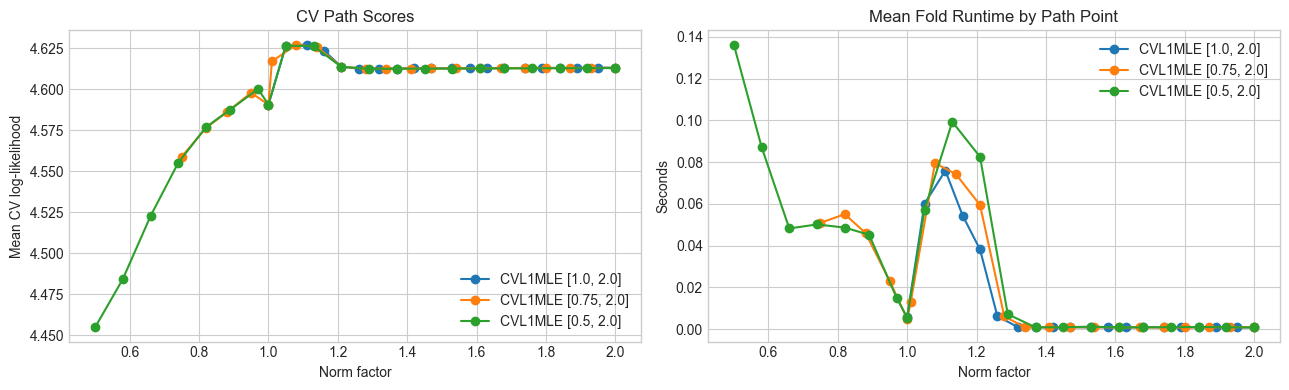

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, fit in range_fits.items():
    path_df = fit["cv_path_df"].copy()
    axes[0].plot(path_df["norm_constraint_factor"], path_df["mean_cv_loglik"], marker="o", label=name)
    axes[1].plot(path_df["norm_constraint_factor"], path_df["mean_runtime_seconds"], marker="o", label=name)
axes[0].set_title("CV Path Scores")
axes[0].set_xlabel("Norm factor")
axes[0].set_ylabel("Mean CV log-likelihood")
axes[1].set_title("Mean Fold Runtime by Path Point")
axes[1].set_xlabel("Norm factor")
axes[1].set_ylabel("Seconds")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


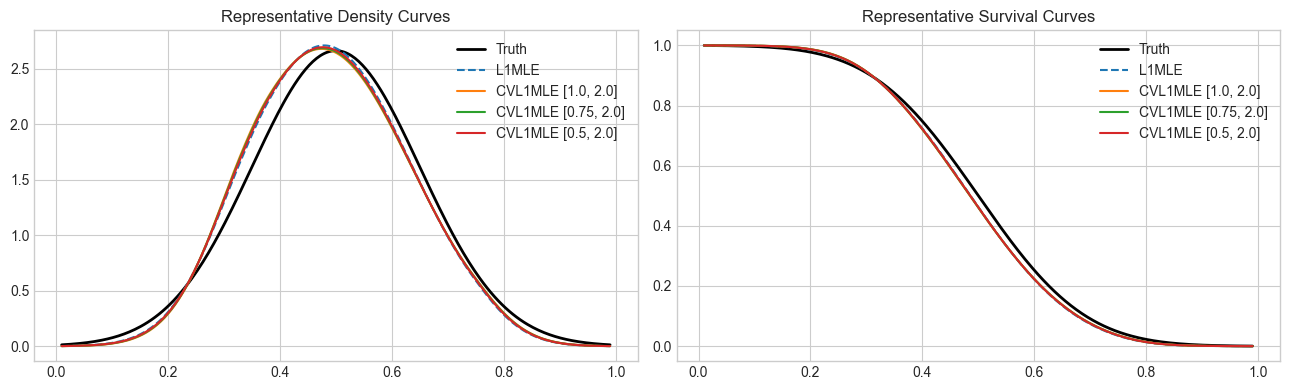

In [5]:
eval_grid = np.linspace(0.01, 0.99, 300)
truth_density = np.asarray(truth["density_fn"](eval_grid), dtype=float)
truth_survival = np.asarray(truth["survival_fn"](eval_grid), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(eval_grid, truth_density, color="black", linewidth=2, label="Truth")
axes[1].plot(eval_grid, truth_survival, color="black", linewidth=2, label="Truth")
axes[0].plot(eval_grid, evaluate_density_on_grid(fixed_l1["estimator"], eval_grid), linestyle="--", label="L1MLE")
axes[1].plot(eval_grid, evaluate_survival_on_grid(fixed_l1["estimator"], eval_grid), linestyle="--", label="L1MLE")
for name, fit in range_fits.items():
    axes[0].plot(eval_grid, evaluate_density_on_grid(fit["estimator"], eval_grid), label=name)
    axes[1].plot(eval_grid, evaluate_survival_on_grid(fit["estimator"], eval_grid), label=name)
axes[0].set_title("Representative Density Curves")
axes[1].set_title("Representative Survival Curves")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


In [6]:

pilot_method_rows = []
pilot_pointwise_rows = []
for seed in PILOT_SEEDS:
    seed_result = run_pilot_seed(seed)
    pilot_method_rows.extend(seed_result["method_rows"])
    pilot_pointwise_rows.extend(seed_result["pointwise_rows"])

pilot_df = pd.DataFrame(pilot_method_rows)
pilot_pointwise_df = pd.DataFrame(pilot_pointwise_rows)
pilot_summary = pilot_df.groupby("method").agg({
    "runtime_seconds": ["mean", "median"],
    "observed_loglik": "mean",
    "density_pointwise_mse": "mean",
    "survival_pointwise_mse": "mean",
    "selected_norm_factor": "mean",
}).sort_values(("density_pointwise_mse", "mean"))
display(pilot_summary)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True

runtime_seconds           observed_loglik  \
                               mean    median            mean   
method                                                          
CVL1MLE [0.5, 2.0]         4.870769  4.399485       22.247253   
CVL1MLE [0.75, 2.0]        2.904057  2.658560       22.283560   
CVL1MLE [1.0, 2.0]         1.527623  1.122317       22.414784   
L1MLE                      0.037755  0.006496       21.406149   

                    density_pointwise_mse survival_pointwise_mse  \
                                     mean                   mean   
method                                                             
CVL1MLE [0.5, 2.0]               0.077550               0.001412   
CVL1MLE [0.75, 2.0]              0.079437               0.001422   
CVL1MLE [1.0, 2.0]               0.081789               0.001418   
L1MLE                            0.090033               0.001762   

                    selected_norm_factor  
                                    mean  
method                                    
CVL1MLE [0.5, 2.0]              1.104667  
CVL1MLE [0.75, 2.0]             1.184000  
CVL1MLE [1.0, 2.0]              1.268000  
L1MLE                           1.000000

/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_638/4177615870.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=plot_order, showfliers=False)
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_638/4177615870.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=plot_order, showfliers=False)
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_638/4177615870.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=plot_order, showfliers=False)


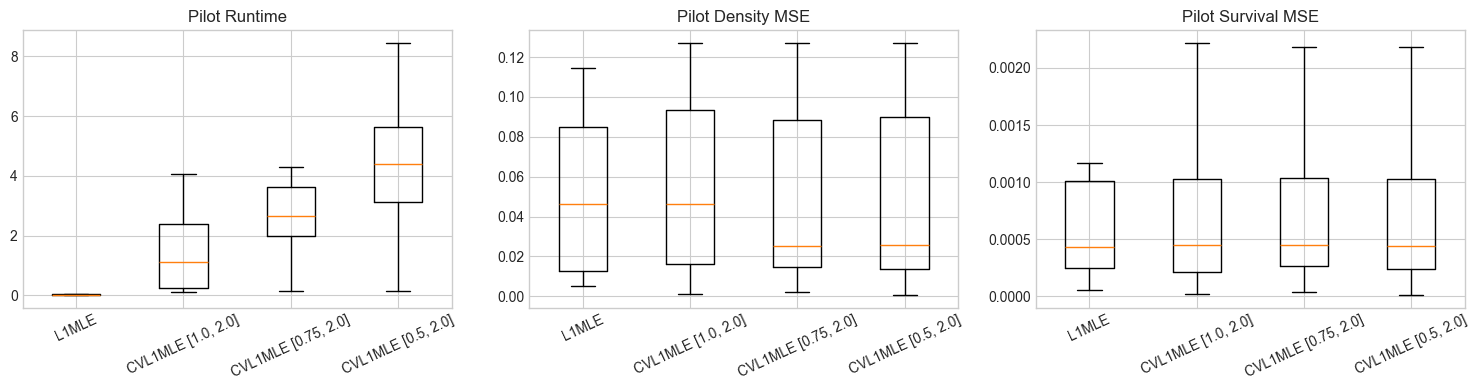

In [7]:
plot_order = ["L1MLE", *RANGE_CONFIGS.keys()]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in [
    (axes[0], "runtime_seconds", "Pilot Runtime"),
    (axes[1], "density_pointwise_mse", "Pilot Density MSE"),
    (axes[2], "survival_pointwise_mse", "Pilot Survival MSE"),
]:
    data_to_plot = [pilot_df.loc[pilot_df["method"] == name, metric].to_numpy(dtype=float) for name in plot_order]
    ax.boxplot(data_to_plot, labels=plot_order, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


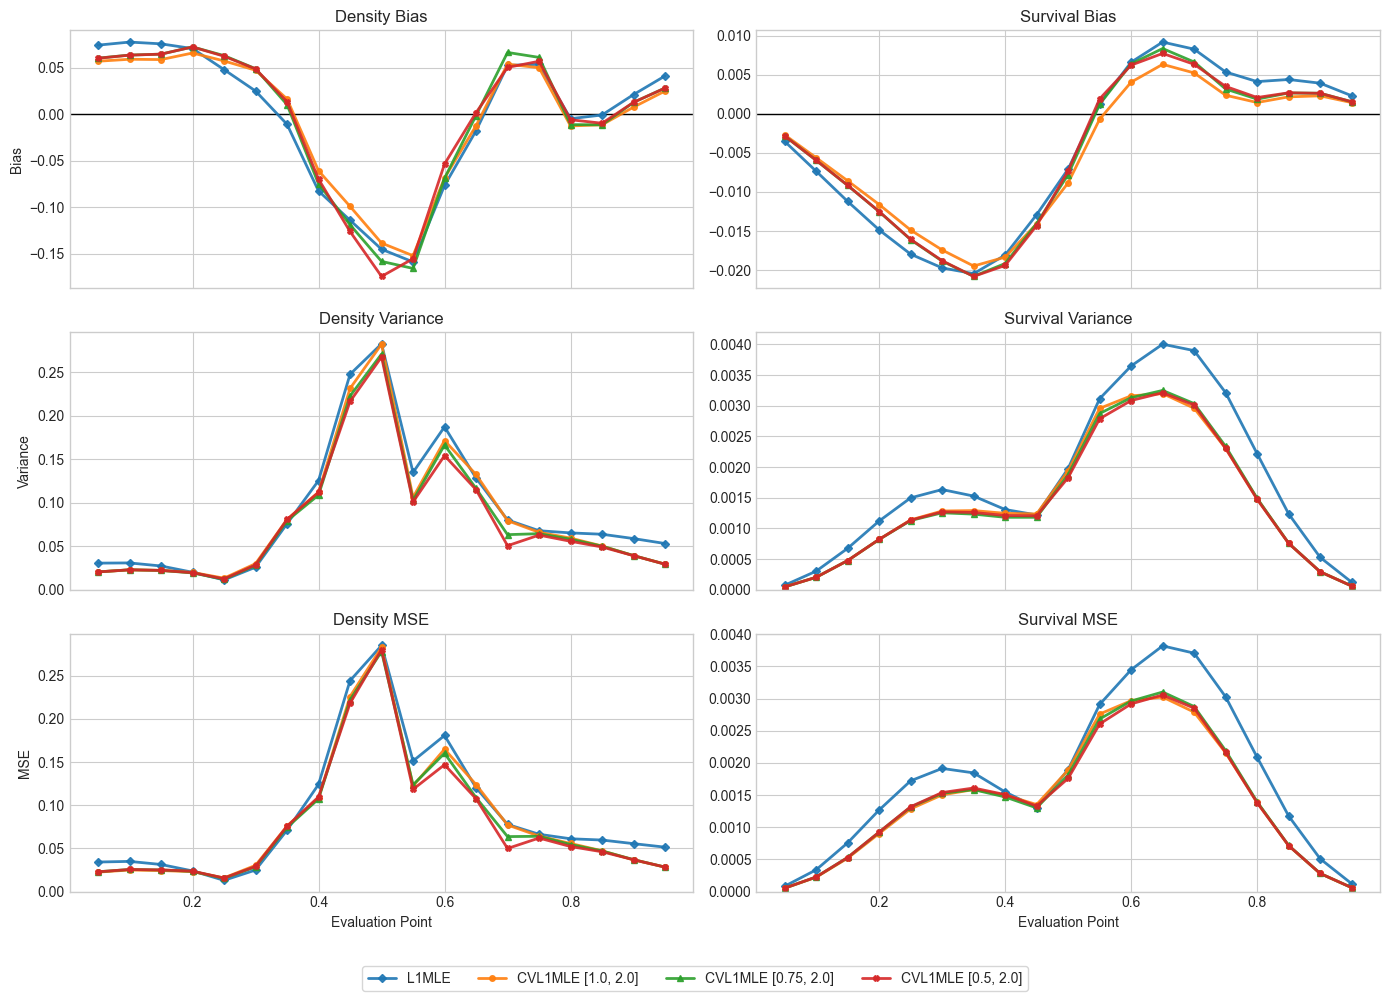

In [8]:

pointwise_metric_summary = (
    pilot_pointwise_df.groupby(["method", "estimand", "eval_point"], as_index=False)
    .agg(
        bias=("error", "mean"),
        variance=("estimate", lambda x: float(np.var(x, ddof=1)) if len(x) > 1 else 0.0),
        mse=("squared_error", "mean"),
    )
)

pointwise_plot_methods = ["L1MLE", *RANGE_CONFIGS.keys()]
pointwise_plot_colors = {
    method: color
    for method, color in zip(pointwise_plot_methods, plt.get_cmap("tab10").colors[: len(pointwise_plot_methods)])
}
pointwise_plot_markers = {
    "L1MLE": "D",
    "CVL1MLE [1.0, 2.0]": "o",
    "CVL1MLE [0.75, 2.0]": "^",
    "CVL1MLE [0.5, 2.0]": "X",
}
metric_order = ["bias", "variance", "mse"]
estimand_order = ["density", "survival"]
metric_labels = {"bias": "Bias", "variance": "Variance", "mse": "MSE"}
estimand_labels = {"density": "Density", "survival": "Survival"}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex="col")

for row_idx, metric in enumerate(metric_order):
    for col_idx, estimand in enumerate(estimand_order):
        ax = axes[row_idx, col_idx]
        if metric == "bias":
            ax.axhline(0.0, color="black", linewidth=1)

        for method in pointwise_plot_methods:
            method_df = pointwise_metric_summary[
                (pointwise_metric_summary["method"] == method)
                & (pointwise_metric_summary["estimand"] == estimand)
            ].sort_values("eval_point")
            ax.plot(
                method_df["eval_point"],
                method_df[metric],
                color=pointwise_plot_colors[method],
                linewidth=2,
                marker=pointwise_plot_markers[method],
                markersize=4,
                alpha=0.9,
                label=method,
            )

        ax.set_title(f"{estimand_labels[estimand]} {metric_labels[metric]}")
        if col_idx == 0:
            ax.set_ylabel(metric_labels[metric])
        if row_idx == len(metric_order) - 1:
            ax.set_xlabel("Evaluation Point")
        if metric in {"variance", "mse"}:
            ax.set_ylim(bottom=0.0)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(pointwise_plot_methods), frameon=True)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


In [ ]:
pilot_df.groupby("method")["density_pointwise_mse"].mean()

method
CVL1MLE [0.5, 2.0]     0.077550
CVL1MLE [0.75, 2.0]    0.079437
CVL1MLE [1.0, 2.0]     0.081789
L1MLE                  0.090033
Name: density_pointwise_mse, dtype: float64